# The Reduced Gradient

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L08/L08_reduced_gradient.ipynb)
### MECH 559 - Systems Optimization - L08

Companion notebook to the "Nonlinear programming" lecture. It works the deck's own reduced-gradient example (Class Exercise 4, Q2) end to end in Python: splitting variables into *state* and *decision* components, deriving the reduced gradient $\nabla w$, solving for stationary points numerically, and cross-checking the result against a direct constrained solve.

## Learning objectives

By the end, students should be able to:

1. Split $x\in\mathbb{R}^n$ into state variables $x_s\in\mathbb{R}^m$ and decision variables $x_d\in\mathbb{R}^p$, $p=n-m$, using the (non-singular) state sub-Jacobian $\nabla_{x_s}h$.
2. Derive and evaluate the reduced gradient $\nabla w^{\mathsf T} = \nabla_{x_d}f^{\mathsf T} - \nabla_{x_s}f^{\mathsf T}(\nabla_{x_s}h)^{-1}\nabla_{x_d}h$.
3. Find stationary points of the reduced problem $\min_{x_d} w(x_d)$ numerically, and confirm they agree with a direct constrained NLP solve.
4. Visualize the feasible curve (here, an ellipse formed by intersecting an ellipsoid and a plane) and see how $w$ varies along it.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"feasible": "#A8DADC", "boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "other": "#6C5B7B"}

print(f"NumPy {np.__version__}, SciPy ok")

NumPy 2.5.2, SciPy ok


---
## 1. The problem

$$
\min_{x\in\mathbb{R}^3} f(x) = x_1^2+x_2^2+x_3^2
\quad\text{s.t.}\quad
h_1(x) = \frac{x_1^2}{4}+\frac{x_2^2}{5}+\frac{x_3^2}{25} - 1 = 0,
\qquad
h_2(x) = x_1+x_2-x_3 = 0.
$$

$h_1=0$ is an ellipsoid, $h_2=0$ is a plane through the origin; together they define an ellipse-shaped curve in $\mathbb{R}^3$ ($n=3$, $m=2$, so $p=1$ degree of freedom - exactly the $n>m$ case from `L08_degrees_of_freedom_and_regularity.ipynb`). $f$ is the squared distance to the origin, so we are looking for the nearest and farthest points on that curve.

Following the slide, we choose $x_1,x_2$ as **state** variables $x_s$ and $x_3$ as the **decision** variable $x_d$.

In [2]:
def f(x):
    return x[0]**2 + x[1]**2 + x[2]**2

def h(x):
    return np.array([
        x[0]**2 / 4 + x[1]**2 / 5 + x[2]**2 / 25 - 1,
        x[0] + x[1] - x[2],
    ])

def grad_f(x):
    return np.array([2 * x[0], 2 * x[1], 2 * x[2]])

def jac_h(x):
    # rows: h1, h2 ; columns: x1, x2, x3
    return np.array([
        [x[0] / 2, 2 * x[1] / 5, 2 * x[2] / 25],
        [1.0,       1.0,          -1.0],
    ])

def split(x):
    # state = (x1, x2), decision = (x3,)
    return x[:2], x[2:]

def reduced_gradient(x):
    J = jac_h(x)
    Js, Jd = J[:, :2], J[:, 2:]          # nabla_xs h (2x2), nabla_xd h (2x1)
    gfull = grad_f(x)
    gfs, gfd = gfull[:2], gfull[2:]      # nabla_xs f (2,), nabla_xd f (1,)
    return gfd - gfs @ np.linalg.solve(Js, Jd)   # nabla w^T, shape (1,)

x_probe = np.array([1.0, 1.0, 1.0])
print("h(x_probe)          =", h(x_probe), " (nonzero: x_probe is not feasible, just testing the machinery)")
print("reduced gradient there =", reduced_gradient(x_probe))

h(x_probe)          = [-0.51  1.  ]  (nonzero: x_probe is not feasible, just testing the machinery)
reduced gradient there = [4.]


---
## 2. Solving $\nabla w = 0$ jointly with $h=0$

> **Predict:** the curve $h_1=h_2=0$ is a closed loop (an ellipse) in $\mathbb{R}^3$. Since $f$ is continuous, how many stationary points of $f$ restricted to that curve do you expect *at least*?

Stationary points of the reduced problem satisfy 3 scalar equations in 3 unknowns: $h_1(x)=0$, $h_2(x)=0$, $\nabla w(x)=0$. We solve this system with `fsolve` from a few different starting points, since a closed curve generally has (at least) one minimum and one maximum of $f$.

In [3]:
def system(x):
    return np.concatenate([h(x), reduced_gradient(x)])

rng = np.random.default_rng(559)
starts = rng.uniform(-3.0, 3.0, size=(40, 3))

solutions = []
for x0 in starts:
    sol, info, ier, msg = fsolve(system, x0, full_output=True)
    if ier == 1 and np.linalg.norm(h(sol)) < 1e-8:
        if not any(np.allclose(sol, s, atol=1e-4) for s in solutions):
            solutions.append(sol)

solutions.sort(key=f)
print(f"found {len(solutions)} distinct stationary points from {len(starts)} random starts:\n")
for i, sol in enumerate(solutions):
    print(f"solution {i}: x = {sol}, f(x) = {f(sol):.6f}, |h(x)| = {np.linalg.norm(h(sol)):.2e}, "
          f"|nabla w| = {np.linalg.norm(reduced_gradient(sol)):.2e}")

found 4 distinct stationary points from 40 random starts:

solution 0: x = [ 1.57377895 -1.37705658  0.19672237], f(x) = 4.411765, |h(x)| = 2.28e-14, |nabla w| = 6.90e-14
solution 1: x = [-1.57377895  1.37705658 -0.19672237], f(x) = 4.411765, |h(x)| = 0.00e+00, |nabla w| = 6.66e-16
solution 2: x = [1.02597835 1.53896753 2.56494588], f(x) = 10.000000, |h(x)| = 1.68e-12, |nabla w| = 5.71e-12
solution 3: x = [-1.02597835 -1.53896753 -2.56494588], f(x) = 10.000000, |h(x)| = 1.20e-15, |nabla w| = 1.43e-13


---
## 3. Cross-check against a direct constrained solve

The reduced-gradient system found candidate stationary points via a 3-equation root-find. As an independent check, we solve the *same* problem directly as a constrained NLP with `scipy.optimize.minimize` (SLSQP) - once minimizing $f$, once maximizing it (minimizing $-f$) - and confirm both approaches agree.

In [4]:
cons = [{"type": "eq", "fun": lambda x: h(x)[0]}, {"type": "eq", "fun": lambda x: h(x)[1]}]

res_min = minimize(f, x0=[1.0, 1.0, 1.0], constraints=cons)
res_max = minimize(lambda x: -f(x), x0=[-1.0, -1.0, -1.0], constraints=cons)

x_min_direct, x_max_direct = res_min.x, res_max.x
x_min_reduced, x_max_reduced = solutions[0], solutions[-1]

print("direct NLP solve  (min f):", x_min_direct, " f =", f(x_min_direct))
print("reduced-gradient  (min f):", x_min_reduced, " f =", f(x_min_reduced))
print("agree?", np.allclose(np.sort(np.abs(x_min_direct)), np.sort(np.abs(x_min_reduced)), atol=1e-3))
print()
print("direct NLP solve  (max f):", x_max_direct, " f =", f(x_max_direct))
print("reduced-gradient  (max f):", x_max_reduced, " f =", f(x_max_reduced))
print("agree?", np.allclose(np.sort(np.abs(x_max_direct)), np.sort(np.abs(x_max_reduced)), atol=1e-3))

direct NLP solve  (min f): [ 1.57377381 -1.3770643   0.19670951]  f = 4.411764706591378
reduced-gradient  (min f): [ 1.57377895 -1.37705658  0.19672237]  f = 4.411764705882253
agree? True

direct NLP solve  (max f): [-1.02597835 -1.53896753 -2.56494588]  f = 10.00000000001662
reduced-gradient  (max f): [-1.02597835 -1.53896753 -2.56494588]  f = 10.00000000000001
agree? True


---
## 4. Visualizing the feasible curve

To draw the curve $h_1=h_2=0$, substitute $x_3=x_1+x_2$ (from $h_2=0$) into $h_1=0$: this gives a quadratic curve (an ellipse) in the $(x_1,x_2)$ plane, which we trace with `matplotlib`'s contour machinery and then lift back to 3D via $x_3=x_1+x_2$.

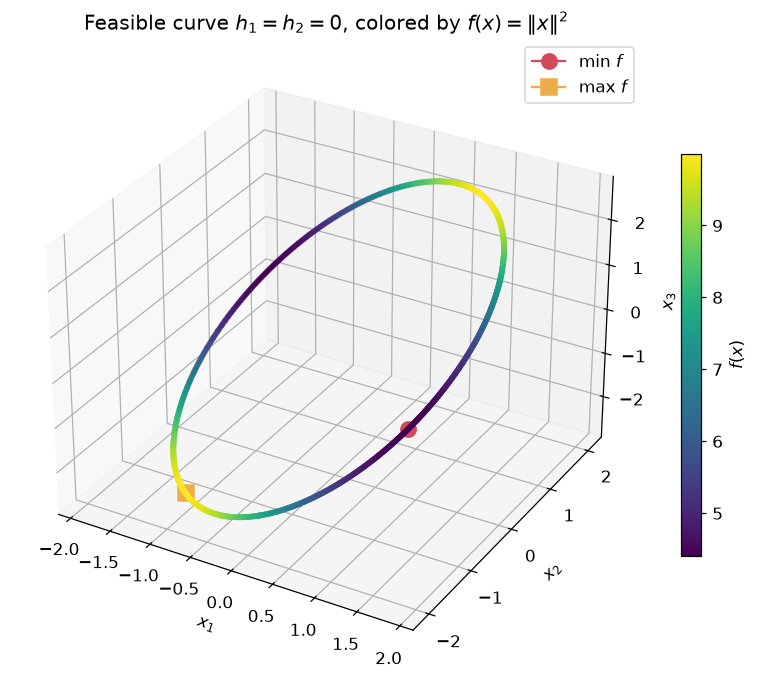

In [5]:
def Q(x1, x2):
    x3 = x1 + x2
    return x1**2 / 4 + x2**2 / 5 + x3**2 / 25

xx1, xx2 = np.meshgrid(np.linspace(-2.5, 2.5, 400), np.linspace(-2.5, 2.5, 400))
fig_tmp, ax_tmp = plt.subplots()
cs = ax_tmp.contour(xx1, xx2, Q(xx1, xx2), levels=[1.0])
verts = cs.allsegs[0][0]
plt.close(fig_tmp)

curve_x1, curve_x2 = verts[:, 0], verts[:, 1]
curve_x3 = curve_x1 + curve_x2
curve_f = curve_x1**2 + curve_x2**2 + curve_x3**2

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(curve_x1, curve_x2, curve_x3, c=curve_f, cmap="viridis", s=8)
ax.plot(*x_min_reduced.reshape(3, 1), marker="o", color=COLORS["optimum"], markersize=10, label="min $f$")
ax.plot(*x_max_reduced.reshape(3, 1), marker="s", color=COLORS["accent"], markersize=10, label="max $f$")
ax.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$",
       title=r"Feasible curve $h_1=h_2=0$, colored by $f(x)=\|x\|^2$")
fig.colorbar(sc, ax=ax, shrink=0.6, label="$f(x)$")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. The reduced problem is genuinely 1D: $w(x_d)$

Because $p=n-m=1$ here, the reduced problem $\min_{x_d} w(x_d)$ is a **univariate** curve we can plot directly: for each candidate $x_3$, solve $h_1=h_2=0$ for the corresponding $(x_1,x_2)$ (there are generically two branches, symmetric about the curve), then evaluate $f$.

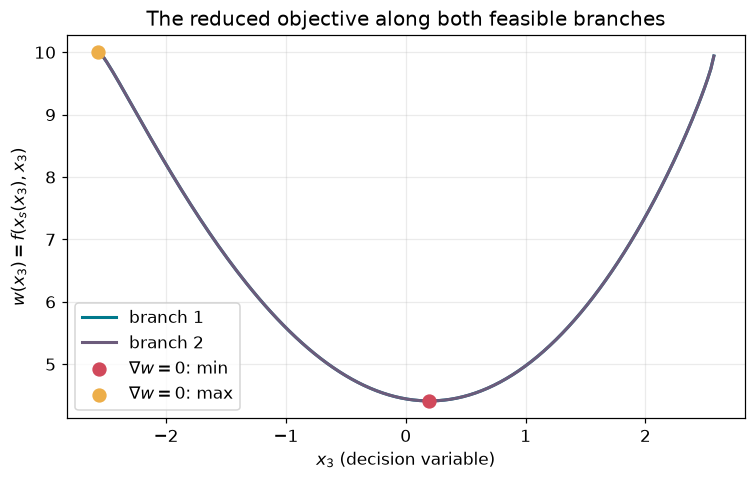

In [6]:
def state_for_decision(x3, xs_guess):
    def resid(xs):
        return h(np.array([xs[0], xs[1], x3]))
    sol = fsolve(resid, xs_guess, full_output=False)
    return sol

x3_min = x_min_reduced[2]
x3_max = x_max_reduced[2]
x3_lo, x3_hi = curve_x3.min(), curve_x3.max()
x3_range = np.linspace(x3_lo + 1e-3, x3_hi - 1e-3, 200)

w_branch1, w_branch2 = [], []
guess1, guess2 = x_min_reduced[:2].copy(), x_max_reduced[:2].copy()
for x3 in x3_range:
    xs1 = state_for_decision(x3, guess1)
    xs2 = state_for_decision(x3, guess2)
    guess1, guess2 = xs1, xs2
    w_branch1.append(f(np.array([*xs1, x3])))
    w_branch2.append(f(np.array([*xs2, x3])))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x3_range, w_branch1, color=COLORS["boundary"], lw=2, label="branch 1")
ax.plot(x3_range, w_branch2, color=COLORS["other"], lw=2, label="branch 2")
ax.scatter([x3_min], [f(x_min_reduced)], color=COLORS["optimum"], zorder=4, s=70, label=r"$\nabla w=0$: min")
ax.scatter([x3_max], [f(x_max_reduced)], color=COLORS["accent"], zorder=4, s=70, label=r"$\nabla w=0$: max")
ax.set(xlabel="$x_3$ (decision variable)", ylabel="$w(x_3) = f(x_s(x_3), x_3)$",
       title="The reduced objective along both feasible branches")
ax.legend()
plt.tight_layout()
plt.show()

Both branches meet exactly where $\nabla w=0$ (they are the same curve, just parametrized by which state-variable root `fsolve` converges to) - the minimum sits at one end of the shared range, the maximum at the other, matching the two stationary points found in Section 2 and confirmed against the direct NLP solve in Section 3. The maximum happens to sit close to where the two branches fold together, i.e. where $\nabla_{x_s}h$ becomes ill-conditioned (it never actually goes singular here - check its determinant yourself). That is a coincidence of this particular example, not a general rule; it is also why parametrizing by $x_3$ alone is a convenient way to *plot* the reduced problem here, but not the recommended way to *solve* it in general (Section 2's joint root-find is more robust).

---
## Takeaways

1. Splitting $x$ into state and decision variables replaces the constrained problem $\min_x f(x)\ \text{s.t.}\ h(x)=0$ with an *unconstrained* problem $\min_{x_d} w(x_d)$ on the $p=n-m$ decision variables - exactly the mechanism that makes the Lagrangian derivation in the next notebook work.
2. The reduced gradient $\nabla w^{\mathsf T}=\nabla_{x_d}f^{\mathsf T}-\nabla_{x_s}f^{\mathsf T}(\nabla_{x_s}h)^{-1}\nabla_{x_d}h$ only needs $\nabla_{x_s}h$ to be non-singular (i.e. the state variables to be a valid regular choice) - not the full $n\times n$ system.
3. Solving $[h(x);\,\nabla w(x)]=0$ with a root-finder and solving the original constrained NLP directly with a constrained optimizer are two different numerical routes to the *same* stationary points - a good habit whenever you eliminate variables by hand.
4. A closed feasible curve with a smooth objective generically has (at least) one min and one max; both are stationary points of $w$, but only one is what you were actually looking for - a preview of why the lecture needs second-order conditions (SOSC) to tell them apart, covered in `L08_lagrangian_and_sosc.ipynb`.

## Optional exercises

1. Re-derive the reduced gradient choosing $x_2,x_3$ as the state variables instead (and $x_1$ as the decision variable). Confirm the same two stationary points emerge.
2. Modify $h_2$ to $x_1+x_2-x_3=c$ for a few values of $c\ne0$ and track how the min/max values of $f$ on the (now differently placed) curve change.
3. The state sub-Jacobian $\nabla_{x_s}h$ must be non-singular for this whole construction to work. Find a point on the feasible curve (if one exists) where choosing $x_1,x_2$ as state variables breaks down, and check whether a different state/decision split works there instead.